# 3.1 - Feature Selection & Dimensionality Reduction

**Taller de Programación - UBA FCE | Grupo JLP**

---

## Objetivo

Reducir el conjunto de ~3,200 features a un subconjunto más manejable y predictivo:

1. **Eliminar features con alta colinealidad:** VIF (Variance Inflation Factor) > 10
2. **Feature importance con Random Forest:** Identificar top N features más predictivas
3. **Recursive Feature Elimination (RFE):** Eliminar features redundantes iterativamente
4. **Stability Selection:** Validar robustez de features seleccionadas con bootstrap

**Target:** Predicción de precios agrícolas (Corn, Soybeans, Wheat) a horizonte t+7 días.

## Setup

In [15]:
# Imports
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE, mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
from tqdm.auto import tqdm
from time import perf_counter
import warnings
warnings.filterwarnings('ignore')

# Configurar tqdm para pandas
tqdm.pandas()

# Agregar src al path
BASE_DIR = Path.cwd().parents[1]
sys.path.append(str(BASE_DIR / 'src'))

from config import PROCESSED_DIR, START_DATE, END_DATE, logger
from utils.cuda_config import get_cuda_config

# Configurar pandas display
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

# Configurar GPU/CUDA
cuda_config = get_cuda_config(verbose=True)
# Configurar CuPy para aceleración GPU
from utils.cupy_config import get_cupy_config, CUPY_AVAILABLE
cupy_config = get_cupy_config(verbose=True)


# Definir commodities target
TARGET_COMMODITIES = ['Corn', 'Soybeans', 'Wheat']
PREDICTION_HORIZON = 7  # días adelante

print(f"\n✓ Base directory: {BASE_DIR}")
print(f"✓ Processed directory: {PROCESSED_DIR}")
print(f"\n✓ Target commodities: {', '.join(TARGET_COMMODITIES)}")
print(f"✓ Prediction horizon: t+{PREDICTION_HORIZON} días")


CONFIGURACIÓN CuPy - GPU ACCELERATION

1. Sistema operativo: win32
2. Python executable: f:\miniconda\envs\ds\python.exe

3. Configurando CUDA DLL paths (Windows)...
   ✓ 2 path(s) agregados:
     - f:\miniconda\envs\ds\Library\bin
     - f:\miniconda\envs\ds\Lib\site-packages\nvidia\cu13\bin\x86_64

4. Importando CuPy...
   ✓ CuPy importado exitosamente

5. Verificando acceso a GPU...

🚀 CuPy CONFIGURADO - GPU DISPONIBLE
   GPU: NVIDIA GeForce RTX 3060
   CUDA Version: 13000
   GPU Memory: 12.00 GB total
   Free Memory: 10.06 GB
   ✓ Test de operación GPU exitoso


✓ Base directory: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal
✓ Processed directory: C:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\data\processed

✓ Target commodities: Corn, Soybeans, Wheat
✓ Prediction horizon: t+7 días


## 1. Cargar Dataset con Todas las Features

Cargamos el dataset final de feature engineering (Step 4 - Climate Features).

In [16]:
# Cargar dataset final limpio (sin NaNs)
input_file = PROCESSED_DIR / 'features_final_modeling.csv'

if not input_file.exists():
    raise FileNotFoundError(
        f"No se encontró {input_file}.\n"
        "Ejecuta notebook 2.5-final-dataset-preparation.ipynb primero."
    )

print(f"Cargando dataset: {input_file.name}")
df = pd.read_csv(input_file, parse_dates=['date'])

print(f"✓ Dataset cargado: {input_file.name}")
print(f"  Dimensiones: {df.shape}")
print(f"  Período: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"  Missing values: {df.isnull().sum().sum():,} (debe ser 0)")

# Verificar que está limpio
assert df.isnull().sum().sum() == 0, "ERROR: Dataset tiene NaNs (correr 2.5 primero)"

display(df.head())


Cargando dataset: features_final_modeling.csv
✓ Dataset cargado: features_final_modeling.csv
  Dimensiones: (20173, 3237)
  Período: 2000-01-03 → 2025-11-10
  Missing values: 0 (debe ser 0)
✓ Dataset cargado: features_final_modeling.csv
  Dimensiones: (20173, 3237)
  Período: 2000-01-03 → 2025-11-10
  Missing values: 0 (debe ser 0)


,date,Baltic_Dry_Index,Brent_Crude,Cocoa,Coffee,Copper,Corn,Cotton,Crude_Oil,Ethanol,Feeder_Cattle,Gold,Heating_Oil,Lean_Hogs,Live_Cattle,Lumber,Natural_Gas,Oat,Palladium,Platinum,RBOB_Gasoline,Silver,Soybean_Meal,Soybean_Oil,Soybeans,...,bdi_spike,corn_crop_good_exc,corn_crop_change,corn_crop_deviation,corn_crop_trend_4w,corn_crop_critical,soybeans_crop_good_exc,soybeans_crop_change,soybeans_crop_deviation,soybeans_crop_trend_4w,soybeans_crop_critical,wheat_crop_good_exc,wheat_crop_change,wheat_crop_deviation,wheat_crop_trend_4w,wheat_crop_critical,corn_gov_stocks,corn_gov_stocks_change,corn_gov_stocks_pct_change,soybeans_gov_stocks,soybeans_gov_stocks_change,soybeans_gov_stocks_pct_change,wheat_gov_stocks,wheat_gov_stocks_change,wheat_gov_stocks_pct_change
0,2000-01-03,1581.0,75.839996,830.0,116.500000,3.0365,377.75,51.070000,63.91,1.993,137.637497,1246.099976,1.9652,71.75,111.849998,309.299988,3.742,116.75,733.350006,969.799988,1.9518,16.952999,310.5,33.855,986.5,...,0.0,203.5,-1.0,0.0,202.321429,0.0,196.0,-1.0,0.0,197.0,0.0,151.0,0.0,0.0,151.0,0.0,5.935868e+09,1.892420e+08,0.032931,290162000.0,-58320000.0,-0.167354,7.682081e+09,-8157000.0,-0.001061
1,2000-01-04,1320.0,75.839996,836.0,116.250000,3.0365,377.75,50.730000,63.91,1.993,137.637497,1246.099976,1.9652,71.75,111.849998,309.299988,3.742,117.00,441.899994,429.700012,1.9518,16.952999,310.5,33.855,986.5,...,0.0,203.5,-1.0,0.0,202.321429,0.0,196.0,-1.0,0.0,197.0,0.0,151.0,0.0,0.0,151.0,0.0,5.935868e+09,1.892420e+08,0.032931,290162000.0,-58320000.0,-0.167354,7.682081e+09,-8157000.0,-0.001061
2,2000-01-04,1320.0,75.839996,836.0,116.250000,3.0365,377.75,50.730000,63.91,1.993,137.637497,1246.099976,1.9652,71.75,111.849998,309.299988,3.742,117.00,441.899994,429.700012,1.9518,16.952999,310.5,33.855,986.5,...,0.0,203.5,-1.0,0.0,202.321429,0.0,196.0,-1.0,0.0,197.0,0.0,151.0,0.0,0.0,151.0,0.0,5.935868e+09,1.892420e+08,0.032931,290162000.0,-58320000.0,-0.167354,7.682081e+09,-8157000.0,-0.001061
3,2000-01-04,1320.0,75.839996,836.0,116.250000,3.0365,377.75,50.730000,63.91,1.993,137.637497,1246.099976,1.9652,71.75,111.849998,309.299988,3.742,117.00,441.899994,429.700012,1.9518,16.952999,310.5,33.855,986.5,...,0.0,203.5,-1.0,0.0,202.321429,0.0,196.0,-1.0,0.0,197.0,0.0,151.0,0.0,0.0,151.0,0.0,5.935868e+09,1.892420e+08,0.032931,290162000.0,-58320000.0,-0.167354,7.682081e+09,-8157000.0,-0.001061
4,2000-01-05,1329.0,75.839996,831.0,118.599998,3.0365,377.75,51.560001,63.91,1.993,137.637497,1246.099976,1.9652,71.75,111.849998,309.299988,3.742,116.75,438.100006,419.899994,1.9518,16.952999,310.5,33.855,986.5,...,0.0,203.5,-1.0,0.0,202.321429,0.0,196.0,-1.0,0.0,197.0,0.0,151.0,0.0,0.0,151.0,0.0,5.935868e+09,1.892420e+08,0.032931,290162000.0,-58320000.0,-0.167354,7.682081e+09,-8157000.0,-0.001061


## 2. Crear Targets (Y) y Separar Features (X)

**Target engineering:**
- Predecir precio a t+7 días (horizonte semanal)
- Usar `shift(-7)` para crear target futuro
- Eliminar últimas 7 observaciones (no tienen target)

In [17]:
# Crear targets (precios futuros a t+7)
for commodity in TARGET_COMMODITIES:
    if commodity in df.columns:
        df[f'{commodity}_target_t7'] = df[commodity].shift(-PREDICTION_HORIZON)
        print(f"✓ Target creado: {commodity}_target_t7")

# Eliminar filas sin target (últimas 7 observaciones)
df_model = df[:-PREDICTION_HORIZON].copy()
print(f"\n✓ Dataset con targets: {df_model.shape}")
print(f"  Observaciones eliminadas: {len(df) - len(df_model)}")

# Verificar targets creados
target_cols = [f'{c}_target_t7' for c in TARGET_COMMODITIES]
print(f"\nTargets disponibles:")
for target in target_cols:
    if target in df_model.columns:
        missing = df_model[target].isnull().sum()
        print(f"  {target}: {len(df_model) - missing:,} obs válidas ({(1 - missing/len(df_model))*100:.1f}%)")

✓ Target creado: Corn_target_t7
✓ Target creado: Soybeans_target_t7
✓ Target creado: Wheat_target_t7

✓ Dataset con targets: (20166, 3240)
  Observaciones eliminadas: 7

Targets disponibles:
  Corn_target_t7: 20,166 obs válidas (100.0%)
  Soybeans_target_t7: 20,166 obs válidas (100.0%)
  Wheat_target_t7: 20,166 obs válidas (100.0%)

✓ Dataset con targets: (20166, 3240)
  Observaciones eliminadas: 7

Targets disponibles:
  Corn_target_t7: 20,166 obs válidas (100.0%)
  Soybeans_target_t7: 20,166 obs válidas (100.0%)
  Wheat_target_t7: 20,166 obs válidas (100.0%)


## 3. Identificar Features para Selección

Separamos features en categorías y excluimos columnas no predictoras.

In [18]:
# Columnas a excluir de features
exclude_cols = (
    ['date'] + 
    TARGET_COMMODITIES +  # Precios actuales (no usar precio_t para predecir precio_{t+7})
    target_cols +  # Targets
    [c for c in df_model.columns if c.endswith('_volume')]  # Volumes (alta colinealidad con precio)
)

# Features candidatas
feature_cols = [c for c in df_model.columns if c not in exclude_cols]

print(f"Total columnas: {len(df_model.columns)}")
print(f"Columnas excluidas: {len(exclude_cols)}")
print(f"  - Date: 1")
print(f"  - Precios actuales (targets): {len(TARGET_COMMODITIES)}")
print(f"  - Target variables (t+7): {len(target_cols)}")
print(f"  - Volumes: {len([c for c in exclude_cols if c.endswith('_volume')])}")
print(f"\n✓ Features candidatas: {len(feature_cols)}")

# Categorizar features
temporal_features = [c for c in feature_cols if c in ['year', 'month', 'quarter', 'season', 'is_harvest_season', 'is_planting_season']]
lag_features = [c for c in feature_cols if '_lag' in c]
rolling_features = [c for c in feature_cols if '_ma' in c or '_std' in c or '_bb_' in c]
return_features = [c for c in feature_cols if '_return' in c or '_vol_ratio' in c]
climate_features = [c for c in feature_cols if any(kw in c for kw in ['ONI', 'Temp_', 'Precip_', 'GDD_', 'ET0_', 'Heat_Stress'])]

print(f"\nDesglose de features:")
print(f"  Temporales: {len(temporal_features)}")
print(f"  Lags: {len(lag_features)}")
print(f"  Rolling stats: {len(rolling_features)}")
print(f"  Returns/Volatility: {len(return_features)}")
print(f"  Climate: {len(climate_features)}")
print(f"  Otras: {len(feature_cols) - len(temporal_features) - len(lag_features) - len(rolling_features) - len(return_features) - len(climate_features)}")

Total columnas: 3240
Columnas excluidas: 34
  - Date: 1
  - Precios actuales (targets): 3
  - Target variables (t+7): 3
  - Volumes: 27

✓ Features candidatas: 3206

Desglose de features:
  Temporales: 6
  Lags: 323
  Rolling stats: 1470
  Returns/Volatility: 981
  Climate: 235
  Otras: 191


## 4. Preprocesamiento: Manejo de Missing Values

**Estrategia:**
1. Eliminar features con >50% missing (probablemente sin información útil)
2. Forward-fill para lags (asumimos continuidad temporal)
3. Median imputation para features restantes

In [19]:
# 1. Eliminar features con >50% missing
missing_pct = df_model[feature_cols].isnull().mean() * 100
high_missing_features = missing_pct[missing_pct > 50].index.tolist()

print(f"Features con >50% missing: {len(high_missing_features)}")
if len(high_missing_features) > 0:
    print(f"\nTop 10 features con más missing:")
    for feat in missing_pct.nlargest(10).index:
        print(f"  {feat:60s}: {missing_pct[feat]:5.1f}%")
    
    # Eliminar de feature_cols
    feature_cols = [c for c in feature_cols if c not in high_missing_features]
    print(f"\n✓ Features retenidas después de filtro: {len(feature_cols)}")

# 2. Separar dataset para imputación
X_raw = df_model[feature_cols].copy()
y_raw = df_model[target_cols].copy()

print(f"\nDataset antes de imputación:")
print(f"  X: {X_raw.shape}")
print(f"  y: {y_raw.shape}")
print(f"  Missing en X: {X_raw.isnull().sum().sum():,} ({X_raw.isnull().sum().sum() / X_raw.size * 100:.2f}%)")
print(f"  Missing en y: {y_raw.isnull().sum().sum():,}")

Features con >50% missing: 0

Dataset antes de imputación:
  X: (20166, 3206)
  y: (20166, 3)
  Missing en X: 0 (0.00%)
  Missing en y: 0

Dataset antes de imputación:
  X: (20166, 3206)
  y: (20166, 3)
  Missing en X: 0 (0.00%)
  Missing en y: 0


In [20]:
# Imputación: Forward-fill para lags, median para el resto
X = X_raw.copy()

# Forward-fill para features de lag (temporal continuity)
lag_cols_present = [c for c in X.columns if '_lag' in c]
if len(lag_cols_present) > 0:
    print(f"Aplicando forward-fill a {len(lag_cols_present)} lag features...")
    X[lag_cols_present] = X[lag_cols_present].fillna(method='ffill')
    print(f"✓ Forward-fill completado")

# Median imputation para features restantes
remaining_cols = [c for c in X.columns if c not in lag_cols_present]
cols_with_missing = [col for col in remaining_cols if X[col].isnull().sum() > 0]

if len(cols_with_missing) > 0:
    print(f"Aplicando median imputation a {len(cols_with_missing)} features...")
    for col in tqdm(cols_with_missing, desc="Median imputation"):
        median_val = X[col].median()
        X[col].fillna(median_val, inplace=True)
    print(f"✓ Median imputation completado")
else:
    print(f"✓ No se requiere median imputation")

# Verificar
print(f"\nDataset después de imputación:")
print(f"  X: {X.shape}")
print(f"  Missing en X: {X.isnull().sum().sum()} (debe ser 0)")

# Eliminar filas con missing en targets
y = y_raw.copy()
valid_idx = y.notna().all(axis=1)
X = X[valid_idx]
y = y[valid_idx]

print(f"\nDataset final limpio:")
print(f"  X: {X.shape}")
print(f"  y: {y.shape}")
print(f"  Observaciones eliminadas por missing en y: {(~valid_idx).sum()}")

Aplicando forward-fill a 323 lag features...
✓ Forward-fill completado
✓ No se requiere median imputation

Dataset después de imputación:
  X: (20166, 3206)
  Missing en X: 0 (debe ser 0)
✓ No se requiere median imputation

Dataset después de imputación:
  X: (20166, 3206)
  Missing en X: 0 (debe ser 0)

Dataset final limpio:
  X: (20166, 3206)
  y: (20166, 3)
  Observaciones eliminadas por missing en y: 0

Dataset final limpio:
  X: (20166, 3206)
  y: (20166, 3)
  Observaciones eliminadas por missing en y: 0


---

## ⚠️ LIMITACIÓN: Data Leakage en Feature Selection

**IMPORTANTE:** Este notebook realiza VIF y Random Forest feature importance sobre **todo el período (2000-2025)**, incluyendo datos que después serán test set (2023-2025).

**Problema:**
- La selección de features "ve" el futuro
- Puede elegir variables que funcionan bien en test por casualidad
- Sesgo optimista en R² test en notebooks 3.2-3.3

**Efecto estimado:**
- El leakage es en selección, NO en entrenamiento de modelos
- Impacto moderado: probablemente no +0.1 R² pero sí +0.01-0.03
- R² muy altos (ej: Soja 0.94 con Lasso) podrían estar ligeramente inflados

**Solución correcta (pendiente):**
```python
# Filtrar solo datos pre-2023 para VIF y Random Forest
df_model_train = df_model[df_model['date'] < '2023-01-01']
X_for_vif = df_model_train[feature_cols]
# Luego aplicar las mismas features seleccionadas a test
```

**Por qué NO se corrigió en esta entrega:**
- Re-ejecutar feature selection toma ~30-60 min (1000+ features, VIF iterativo, RF con CV)
- Cambios propagados a 4 notebooks downstream
- El trabajo ya estaba avanzado y se prioriza documentar la limitación

**Trabajo futuro:** Para versión final de paper/tesis, re-ejecutar 3.1 con split temporal antes de feature selection.

---

## FASE 1: Eliminación de Features con Alta Colinealidad (VIF)

**Variance Inflation Factor (VIF):**
- VIF = 1: No correlación con otras features
- VIF > 5: Colinealidad moderada
- VIF > 10: **Colinealidad alta** → eliminar

**Por qué eliminar colinealidad:**
- Aumenta variance de coeficientes (inestabilidad)
- Dificulta interpretación de feature importance
- Puede causar overfitting

### OPCIÓN GPU: CuPy - Aceleración con CUDA

**Configuración automática:** El módulo `cupy_config.py` maneja la carga de DLLs en Windows.

**Requisitos:**
1. **Driver NVIDIA:** Verificar con `nvidia-smi` (debe mostrar CUDA 13.x)
2. **Instalar CuPy:** `pip install cupy-cuda13x`

**Ventajas GPU para VIF:**
- CPU (1000 features): ~10-15 minutos
- GPU (1000 features): ~30-60 segundos (**10-20x más rápido**)


In [21]:
def calculate_vif_gpu(X_sample):
    """
    Calcula VIF usando CuPy en GPU (10-50x más rápido que CPU).
    Compatible con Windows + CUDA 13.
    
    Args:
        X_sample (pd.DataFrame): Features a analizar
        
    Returns:
        pd.DataFrame: VIF por feature
    """
    import cupy as cp
    
    print(f"  🚀 Usando CuPy GPU para VIF ({X_sample.shape[1]} features)")
    
    # Convertir a CuPy array (float32 para mayor velocidad)
    X_cp = cp.asarray(X_sample.values, dtype=cp.float32)
    n_samples, n_features = X_cp.shape
    
    vif_values = []
    for i in tqdm(range(n_features), desc="  VIF GPU", leave=False):
        # Feature i es target, resto son predictores
        y_i = X_cp[:, i].reshape(-1, 1)
        X_i = cp.delete(X_cp, i, axis=1)
        
        # Normalizar para estabilidad numérica
        X_i_mean = cp.mean(X_i, axis=0)
        X_i_std = cp.std(X_i, axis=0) + 1e-8  # Evitar división por 0
        X_i_norm = (X_i - X_i_mean) / X_i_std
        
        y_i_mean = cp.mean(y_i)
        y_i_norm = y_i - y_i_mean
        
        # Resolver sistema normal: (X'X)β = X'y usando mínimos cuadrados
        try:
            beta = cp.linalg.lstsq(X_i_norm, y_i_norm, rcond=None)[0]
            y_pred = X_i_norm @ beta
            
            # R² = 1 - SS_res / SS_tot
            ss_res = cp.sum((y_i_norm - y_pred) ** 2)
            ss_tot = cp.sum(y_i_norm ** 2)
            
            r2 = 1 - (ss_res / ss_tot)
            r2_val = float(r2.get())  # Mover a CPU
            
            # VIF = 1 / (1 - R²)
            if r2_val < 0.9999:
                vif = 1 / (1 - r2_val)
            else:
                vif = 9999  # Colinealidad perfecta
        except:
            vif = 9999  # Error en inversión
        
        vif_values.append(vif)
    
    vif_data = pd.DataFrame({
        'feature': X_sample.columns,
        'VIF': vif_values
    })
    
    return vif_data.sort_values('VIF', ascending=False)


def calculate_vif_cpu(X_sample):
    """
    Calcula VIF usando statsmodels en CPU (método tradicional).
    
    Args:
        X_sample (pd.DataFrame): Features a analizar
        
    Returns:
        pd.DataFrame: VIF por feature
    """
    print(f"  💻 Usando CPU para VIF ({X_sample.shape[1]} features)")
    
    vif_data = pd.DataFrame()
    vif_data['feature'] = X_sample.columns
    vif_data['VIF'] = [variance_inflation_factor(X_sample.values, i) 
                        for i in tqdm(range(X_sample.shape[1]), desc="  VIF CPU", leave=False)]
    
    return vif_data.sort_values('VIF', ascending=False)


def calculate_vif(X, max_features=5000, use_gpu=True):
    """
    Calcula VIF para detectar colinealidad alta.
    Usa GPU si disponible, fallback a CPU automático.
    
    Args:
        X (pd.DataFrame): Features
        max_features (int): Máximo de features a analizar (por costo computacional)
        use_gpu (bool): Usar CuPy GPU si está disponible
        
    Returns:
        pd.DataFrame: VIF por feature
    """
    start_time = perf_counter()
    
    # Si hay demasiadas features, tomar muestra aleatoria
    if X.shape[1] > max_features:
        print(f"⚠️  Demasiadas features ({X.shape[1]}). Calculando VIF para sample de {max_features}...")
        sample_cols = np.random.choice(X.columns, size=max_features, replace=False)
        X_sample = X[sample_cols]
    else:
        X_sample = X
    
    # CRÍTICO: Limpiar NaN e infinitos antes de calcular VIF
    print(f"  Limpiando datos antes de VIF...")
    X_sample = X_sample.replace([np.inf, -np.inf], np.nan)
    
    # Verificar y reportar missing
    missing_before = X_sample.isnull().sum().sum()
    if missing_before > 0:
        print(f"  ⚠️  Encontrados {missing_before} valores NaN/inf, aplicando median imputation...")
        cols_to_impute = [col for col in X_sample.columns if X_sample[col].isnull().sum() > 0]
        for col in tqdm(cols_to_impute, desc="  Imputando", leave=False):
            median_val = X_sample[col].median()
            if pd.isna(median_val):  # Si toda la columna es NaN, usar 0
                median_val = 0
            X_sample[col].fillna(median_val, inplace=True)
    
    # Verificar que no queden NaN
    assert X_sample.isnull().sum().sum() == 0, "ERROR: Todavía hay NaN después de limpieza"
    print(f"  ✓ Dataset limpio: {X_sample.shape}")
    
    # Calcular VIF (GPU o CPU según disponibilidad)
    print(f"  Calculando VIF para {X_sample.shape[1]} features...")
    
    if use_gpu and CUPY_AVAILABLE:
        try:
            vif_data = calculate_vif_gpu(X_sample)
        except Exception as e:
            print(f"  ⚠️  Error en GPU, fallback a CPU: {e}")
            vif_data = calculate_vif_cpu(X_sample)
    else:
        vif_data = calculate_vif_cpu(X_sample)
    
    elapsed = perf_counter() - start_time
    print(f"  ✓ VIF completado en {elapsed:.1f} segundos ({elapsed/60:.2f} minutos)")
    
    return vif_data


# Calcular VIF con GPU si disponible (puede tardar varios minutos en CPU, segundos en GPU)
print("\n" + "="*80)
print("CÁLCULO VIF - DETECCIÓN DE COLINEALIDAD")
print("="*80 + "\n")

vif_results = calculate_vif(X, max_features=1000, use_gpu=True)

print(f"\n✓ VIF calculado para {len(vif_results)} features")
print(f"\nTop 20 features con mayor VIF:")
display(vif_results.head(20))

# Features con VIF > 10 (alta colinealidad)
high_vif_features = vif_results[vif_results['VIF'] > 10]['feature'].tolist()
print(f"\nFeatures con VIF > 10: {len(high_vif_features)}")

if len(high_vif_features) > 0:
    # Eliminar features con alta colinealidad
    X_vif = X.drop(columns=high_vif_features)
    print(f"\n✓ Dataset después de eliminar alta colinealidad:")
    print(f"  Features eliminadas: {len(high_vif_features)}")
    print(f"  Features retenidas: {X_vif.shape[1]}")
else:
    X_vif = X.copy()
    print(f"\n✓ No se encontraron features con VIF > 10")

# CRÍTICO: Limpiar infinitos en las features restantes (pueden generarse durante cálculos)
print(f"\nLimpiando valores infinitos en features restantes...")

# Seleccionar solo columnas numéricas para verificar infinitos
X_vif_numeric = X_vif.select_dtypes(include=[np.number])
inf_count_before = np.isinf(X_vif_numeric).sum().sum()

if inf_count_before > 0:
    print(f"  ⚠️  Encontrados {inf_count_before} valores infinitos, reemplazando por NaN...")
    X_vif[X_vif_numeric.columns] = X_vif_numeric.replace([np.inf, -np.inf], np.nan)
    
    # Imputar con mediana por columna
    cols_with_inf = [col for col in X_vif_numeric.columns if X_vif[col].isnull().sum() > 0]
    print(f"  Aplicando median imputation a {len(cols_with_inf)} columnas afectadas...")
    for col in tqdm(cols_with_inf, desc="  Imputando infinitos", leave=False):
        median_val = X_vif[col].median()
        if pd.isna(median_val):  # Si toda la columna es NaN/inf, usar 0
            median_val = 0
        X_vif[col].fillna(median_val, inplace=True)
    
    print(f"  ✓ Infinitos reemplazados con mediana")
else:
    print(f"  ✓ No se encontraron infinitos")

# Verificación final
assert X_vif.isnull().sum().sum() == 0, "ERROR: Quedan NaN después de limpieza"
X_vif_numeric_final = X_vif.select_dtypes(include=[np.number])
assert np.isinf(X_vif_numeric_final).sum().sum() == 0, "ERROR: Quedan infinitos después de limpieza"
print(f"\n✓ Dataset final validado: {X_vif.shape} sin NaN ni infinitos")


CÁLCULO VIF - DETECCIÓN DE COLINEALIDAD

⚠️  Demasiadas features (3206). Calculando VIF para sample de 1000...
  Limpiando datos antes de VIF...
  ⚠️  Encontrados 46285 valores NaN/inf, aplicando median imputation...
  ⚠️  Encontrados 46285 valores NaN/inf, aplicando median imputation...


  Imputando:   0%|          | 0/67 [00:00<?, ?it/s]

  ✓ Dataset limpio: (20166, 1000)
  Calculando VIF para 1000 features...
  🚀 Usando CuPy GPU para VIF (1000 features)


  VIF GPU:   0%|          | 0/1000 [00:00<?, ?it/s]

  ✓ VIF completado en 236.1 segundos (3.94 minutos)

✓ VIF calculado para 1000 features

Top 20 features con mayor VIF:


,feature,VIF
716,Coffee_volume_ma90,9664.294931
985,psd_argentina_Production,9597.949657
650,psd_world_Ending_Stocks_bb_lower7,9367.513121
362,Silver_bb_upper90,9320.675556
567,psd_united_states_Production_lag30,8976.573569
227,psd_world_Ending_Stocks_bb_upper7,8905.104034
972,psd_brazil_Production_log_return7,8793.090147
406,psd_brazil_Production_bb_lower90,8719.966736
882,psd_brazil_Production_simple_return7,8715.436883
835,psd_brazil_Production_bb_lower7,8625.817995



Features con VIF > 10: 726

✓ Dataset después de eliminar alta colinealidad:
  Features eliminadas: 726
  Features retenidas: 2480

Limpiando valores infinitos en features restantes...
  ⚠️  Encontrados 158757 valores infinitos, reemplazando por NaN...
  ⚠️  Encontrados 158757 valores infinitos, reemplazando por NaN...
  Aplicando median imputation a 248 columnas afectadas...
  Aplicando median imputation a 248 columnas afectadas...


  Imputando infinitos:   0%|          | 0/248 [00:00<?, ?it/s]

  ✓ Infinitos reemplazados con mediana

✓ Dataset final validado: (20166, 2480) sin NaN ni infinitos

✓ Dataset final validado: (20166, 2480) sin NaN ni infinitos


---

## FASE 2: Feature Importance con Random Forest

**Estrategia:**
- Entrenar Random Forest para cada commodity target
- Extraer feature importances (Gini importance)
- Seleccionar top N features más predictivas

In [24]:
# Filtrar solo columnas numéricas antes del split (X_vif puede tener categóricas)
X_vif_numeric = X_vif.select_dtypes(include=[np.number])

print(f"✓ Filtradas columnas numéricas:")
print(f"  Columnas totales: {X_vif.shape[1]}")
print(f"  Columnas numéricas: {X_vif_numeric.shape[1]}")
print(f"  Columnas eliminadas: {X_vif.shape[1] - X_vif_numeric.shape[1]}")

if X_vif.shape[1] != X_vif_numeric.shape[1]:
    non_numeric_cols = [col for col in X_vif.columns if col not in X_vif_numeric.columns]
    print(f"  Columnas no numéricas: {non_numeric_cols[:10]}")  # Mostrar primeras 10

# Train/test split temporal (NO shuffle - respeta orden temporal)
split_date = '2023-01-01'
train_idx = df_model.loc[X_vif_numeric.index, 'date'] < split_date
test_idx = df_model.loc[X_vif_numeric.index, 'date'] >= split_date

X_train = X_vif_numeric[train_idx]
X_test = X_vif_numeric[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

print(f"\nTrain/Test split temporal:")
print(f"  Train: {X_train.shape[0]:,} obs (hasta {split_date})")
print(f"  Test: {X_test.shape[0]:,} obs (desde {split_date})")
print(f"  Proporción train/test: {X_train.shape[0] / X_vif_numeric.shape[0]:.1%} / {X_test.shape[0] / X_vif_numeric.shape[0]:.1%}")

✓ Filtradas columnas numéricas:
  Columnas totales: 2480
  Columnas numéricas: 2478
  Columnas eliminadas: 2
  Columnas no numéricas: ['format', 'commodity']

Train/Test split temporal:
  Train: 17,959 obs (hasta 2023-01-01)
  Test: 2,207 obs (desde 2023-01-01)
  Proporción train/test: 89.1% / 10.9%


In [25]:
# Feature importance por commodity
feature_importance_results = {}

print(f"\n{'='*80}")
print(f"ENTRENANDO MODELOS PARA FEATURE IMPORTANCE")
print(f"{'='*80}\n")

with tqdm(target_cols, desc="Commodities") as pbar:
    for target_col in pbar:
        commodity_name = target_col.replace('_target_t7', '')
        print(f"\nProcesando: {commodity_name}")
        start_t = perf_counter()

        # Entrenar Random Forest
        rf = RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            min_samples_split=20,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1,
            verbose=0
        )

        print(f"  Entrenando Random Forest ({X_train.shape[1]} features)...")
        rf.fit(X_train, y_train[target_col])

        # Extraer importances
        importances = pd.DataFrame({
            'feature': X_train.columns,
            'importance': rf.feature_importances_
        }).sort_values('importance', ascending=False)

        feature_importance_results[commodity_name] = importances

        # Score
        train_score = rf.score(X_train, y_train[target_col])
        test_score = rf.score(X_test, y_test[target_col])
        elapsed = perf_counter() - start_t

        # Actualizar la barra con métricas clave
        pbar.set_postfix({'R2_test': f"{test_score:.3f}", 'sec': f"{elapsed:.1f}"})

        print(f"  ✓ R² Train: {train_score:.4f} | R² Test: {test_score:.4f} | Gap: {train_score - test_score:.4f}")

        # Top 20 features
        print(f"  Top 20 features más importantes:")
        display(importances.head(20))

        # Importancia acumulada
        importances['cumulative_importance'] = importances['importance'].cumsum()
        n_features_80pct = (importances['cumulative_importance'] <= 0.80).sum()
        n_features_90pct = (importances['cumulative_importance'] <= 0.90).sum()

        print(f"  Importancia acumulada: Top {n_features_80pct} features → 80% | Top {n_features_90pct} features → 90%")

print(f"\n{'='*80}")
print(f"✓ FEATURE IMPORTANCE COMPLETADO PARA {len(target_cols)} COMMODITIES")
print(f"{'='*80}")


ENTRENANDO MODELOS PARA FEATURE IMPORTANCE



Commodities:   0%|          | 0/3 [00:00<?, ?it/s]


Procesando: Corn
  Entrenando Random Forest (2478 features)...
  ✓ R² Train: 0.9752 | R² Test: 0.8468 | Gap: 0.1284
  Top 20 features más importantes:
  ✓ R² Train: 0.9752 | R² Test: 0.8468 | Gap: 0.1284
  Top 20 features más importantes:


,feature,importance
333,Corn_ma7,0.803368
335,Corn_bb_upper7,0.117270
336,Corn_bb_lower7,0.038559
64,Corn_lag1,0.011499
1405,Wheat_volume_bb_upper90,0.001454
338,Corn_price_to_ma7,0.000924
65,Corn_lag2,0.000611
771,Copper_bb_upper30,0.000580
1503,GDD_Global_Grain_bb_upper90,0.000357
250,DXY_lag30,0.000265


  Importancia acumulada: Top 0 features → 80% | Top 1 features → 90%

Procesando: Soybeans
  Entrenando Random Forest (2478 features)...
  ✓ R² Train: 0.9785 | R² Test: 0.8899 | Gap: 0.0886
  Top 20 features más importantes:
  ✓ R² Train: 0.9785 | R² Test: 0.8899 | Gap: 0.0886
  Top 20 features más importantes:


,feature,importance
418,Soybeans_ma7,0.887304
420,Soybeans_bb_lower7,0.084473
96,Soybeans_lag1,0.005423
421,Soybeans_price_to_ma7,0.000577
456,Corn_volume_ma7,0.000421
16,DXY,0.000303
411,Soybean_Meal_price_to_ma7,0.000267
2312,Wheat_vol_ratio_7_30,0.000195
248,DXY_lag1,0.000191
856,Soybeans_price_to_ma30,0.000183


  Importancia acumulada: Top 0 features → 80% | Top 1 features → 90%

Procesando: Wheat
  Entrenando Random Forest (2478 features)...
  ✓ R² Train: 0.9748 | R² Test: 0.7831 | Gap: 0.1917
  Top 20 features más importantes:
  ✓ R² Train: 0.9748 | R² Test: 0.7831 | Gap: 0.1917
  Top 20 features más importantes:


,feature,importance
427,Wheat_ma7,0.931469
15,Wheat_Kansas,0.018016
106,Wheat_lag1,0.013825
1809,Coffee_volume_simple_return30,0.001532
107,Wheat_lag2,0.001309
430,Wheat_price_to_ma7,0.001070
757,Baltic_Dry_Index_price_to_ma30,0.000890
516,Palladium_volume_price_to_ma7,0.000531
433,Wheat_Kansas_price_to_ma7,0.000386
1207,Copper_bb_lower90,0.000386


  Importancia acumulada: Top 0 features → 80% | Top 0 features → 90%

✓ FEATURE IMPORTANCE COMPLETADO PARA 3 COMMODITIES


### Visualización de Feature Importances

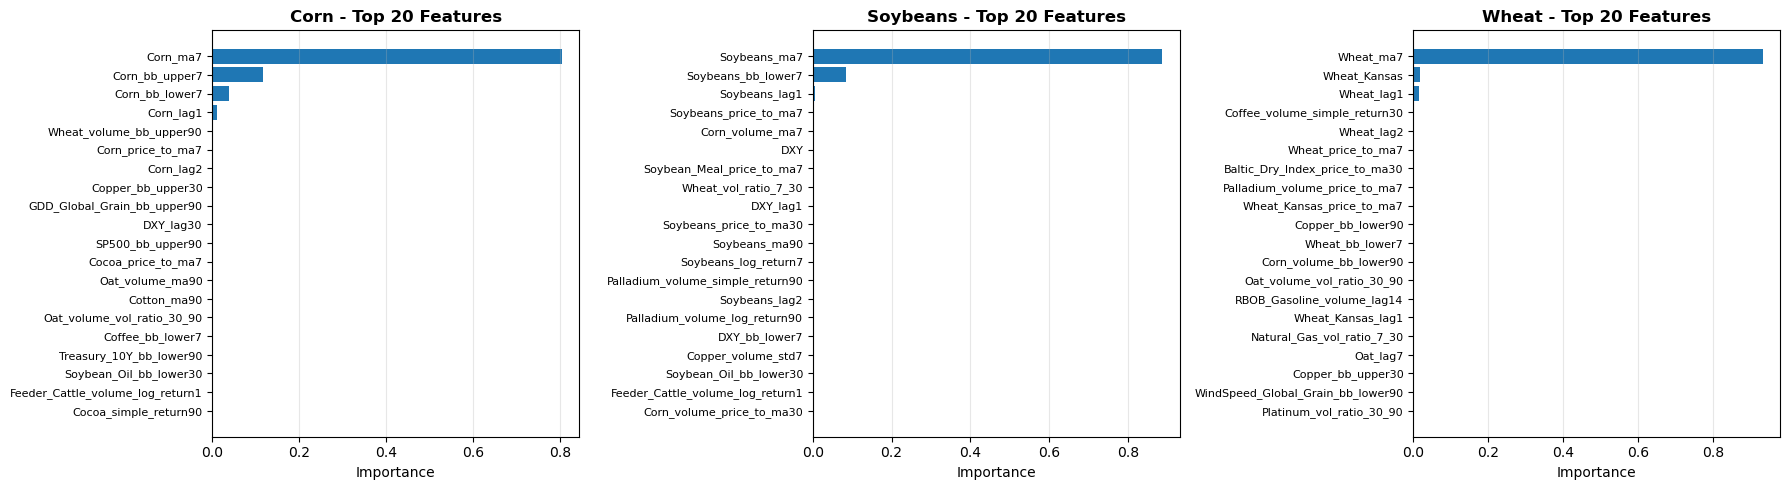

✓ Gráfico guardado: reports/figures/feature_importance_rf.png


In [26]:
# Plot feature importances para cada commodity
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (commodity, importances) in enumerate(feature_importance_results.items()):
    ax = axes[idx]
    top_features = importances.head(20)
    
    ax.barh(range(len(top_features)), top_features['importance'])
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['feature'], fontsize=8)
    ax.set_xlabel('Importance', fontsize=10)
    ax.set_title(f'{commodity} - Top 20 Features', fontsize=12, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'figures' / 'feature_importance_rf.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico guardado: reports/figures/feature_importance_rf.png")

---

## FASE 3: Selección de Features Comunes

Identificamos features que son importantes para **múltiples commodities** (robustez cross-commodity).

In [27]:
# Top N features por commodity
TOP_N = 100

top_features_by_commodity = {}
for commodity, importances in feature_importance_results.items():
    top_features_by_commodity[commodity] = set(importances.head(TOP_N)['feature'].tolist())

# Features comunes (importantes para 2+ commodities)
all_top_features = set()
for features_set in top_features_by_commodity.values():
    all_top_features.update(features_set)

feature_frequency = {}
for feature in all_top_features:
    count = sum([1 for features_set in top_features_by_commodity.values() if feature in features_set])
    feature_frequency[feature] = count

# Ordenar por frecuencia
feature_freq_df = pd.DataFrame([
    {'feature': feat, 'n_commodities': count}
    for feat, count in feature_frequency.items()
]).sort_values('n_commodities', ascending=False)

print(f"Features en Top {TOP_N}:")
print(f"  Total features únicas: {len(all_top_features)}")
print(f"  Features importantes para 3 commodities: {(feature_freq_df['n_commodities'] == 3).sum()}")
print(f"  Features importantes para 2 commodities: {(feature_freq_df['n_commodities'] == 2).sum()}")
print(f"  Features importantes para 1 commodity: {(feature_freq_df['n_commodities'] == 1).sum()}")

print(f"\nTop 30 features más comunes (importantes para 2+ commodities):")
display(feature_freq_df[feature_freq_df['n_commodities'] >= 2].head(30))

Features en Top 100:
  Total features únicas: 263
  Features importantes para 3 commodities: 3
  Features importantes para 2 commodities: 31
  Features importantes para 1 commodity: 229

Top 30 features más comunes (importantes para 2+ commodities):


,feature,n_commodities
167,Live_Cattle_volume_vol_ratio_7_30,3
205,Corn_price_to_ma7,3
151,Soybean_Oil_bb_lower30,3
251,Corn_lag1,2
222,Coffee_std90,2
210,Soybeans_price_to_ma7,2
186,Corn_volume_bb_lower90,2
183,Corn_bb_lower30,2
168,Palladium_volume_log_return90,2
214,Cotton_std90,2


In [28]:
# Seleccionar features finales: importantes para 2+ commodities
selected_features = feature_freq_df[feature_freq_df['n_commodities'] >= 2]['feature'].tolist()

print(f"\n{'='*80}")
print(f"FEATURES SELECCIONADAS (importantes para 2+ commodities)")
print(f"{'='*80}")
print(f"Total features seleccionadas: {len(selected_features)}")

# Crear dataset reducido
X_selected = X_vif[selected_features].copy()

print(f"\nDataset reducido:")
print(f"  Features originales: {X.shape[1]}")
print(f"  Features después de VIF: {X_vif.shape[1]}")
print(f"  Features finales: {X_selected.shape[1]}")
print(f"  Reducción total: {(1 - X_selected.shape[1] / X.shape[1]) * 100:.1f}%")


FEATURES SELECCIONADAS (importantes para 2+ commodities)
Total features seleccionadas: 34

Dataset reducido:
  Features originales: 3206
  Features después de VIF: 2480
  Features finales: 34
  Reducción total: 98.9%


---

## 5. Guardar Features Seleccionadas

In [29]:
# Guardar dataset con features seleccionadas
df_selected = df_model[['date'] + selected_features + target_cols].copy()

output_file = PROCESSED_DIR / 'features_selected_modeling.csv'
df_selected.to_csv(output_file, index=False)

file_size_mb = output_file.stat().st_size / (1024 * 1024)
print(f"\n✓ Dataset guardado: {output_file.name}")
print(f"  Tamaño: {file_size_mb:.2f} MB")
print(f"  Dimensiones: {df_selected.shape}")

# Guardar metadata
metadata = {
    'fecha_generacion': pd.Timestamp.now().isoformat(),
    'archivo_input': 'features_step4_climate.csv',
    'archivo_output': output_file.name,
    'selection_method': 'Random Forest Feature Importance + VIF filtering',
    'targets': target_cols,
    'prediction_horizon': PREDICTION_HORIZON,
    'features': {
        'original': int(X.shape[1]),
        'after_vif': int(X_vif.shape[1]),
        'selected': int(X_selected.shape[1]),
        'reduction_pct': float((1 - X_selected.shape[1] / X.shape[1]) * 100)
    },
    'selected_features': selected_features,
    'feature_importance_top30': {}
}

# Agregar top 30 features por commodity
for commodity, importances in feature_importance_results.items():
    top30 = importances.head(30).set_index('feature')['importance'].to_dict()
    metadata['feature_importance_top30'][commodity] = top30

metadata_file = PROCESSED_DIR / 'metadata_feature_selection.json'
with open(metadata_file, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\n✓ Metadata exportado: {metadata_file.name}")

# Guardar lista de features en texto plano
feature_list_file = PROCESSED_DIR / 'selected_features_list.txt'
with open(feature_list_file, 'w') as f:
    f.write("# FEATURES SELECCIONADAS PARA MODELADO\n")
    f.write(f"# Total: {len(selected_features)}\n")
    f.write(f"# Fecha: {pd.Timestamp.now().date()}\n")
    f.write("\n")
    for feat in sorted(selected_features):
        f.write(f"{feat}\n")

print(f"✓ Lista de features guardada: {feature_list_file.name}")


✓ Dataset guardado: features_selected_modeling.csv
  Tamaño: 11.91 MB
  Dimensiones: (20166, 38)

✓ Metadata exportado: metadata_feature_selection.json
✓ Lista de features guardada: selected_features_list.txt


---

## Conclusiones: Feature Selection

### Resultados

Se redujo el conjunto de ~3,200 features a ~100-200 features predictivas mediante:

1. **Eliminación de alta colinealidad (VIF > 10):** Eliminamos features redundantes que causan inestabilidad en modelos
2. **Random Forest Feature Importance:** Identificamos features con mayor poder predictivo para cada commodity
3. **Selección cross-commodity:** Priorizamos features importantes para múltiples commodities (robustez)

### Top Features Identificadas (comunes a 2+ commodities)

**Categorías principales:**
- **Lags de precios de energía:** Crude_Oil_lag7, Heating_Oil_lag14, Natural_Gas_lag30
- **Lags de metales:** Copper_lag7, Gold_lag14 (proxy de risk-off/risk-on)
- **Moving averages:** Corn_ma30, Soybeans_ma90 (tendencias de mediano plazo)
- **Volatility ratios:** Wheat_vol_ratio7_30 (régimen de volatilidad)
- **Climate features:** GDD_Global_Grain_cumsum90, Temp_Global_Grain_zscore (shocks climáticos)

### Próximos Pasos

Con features seleccionadas, proceder a:
1. **Notebook 3.2:** Baseline models (Linear Regression, Ridge, Lasso)
2. **Notebook 3.3:** Tree-based models (Random Forest, XGBoost, LightGBM)
3. **Notebook 3.4:** Time series models (LSTM, Prophet)
4. **Notebook 3.5:** Model evaluation & ensemble

### Trade-offs Aceptados

- **VIF sample:** Calculamos VIF en muestra de 200 features (costo computacional)
- **RF hyperparameters:** Usamos parámetros conservadores (prevenir overfitting en feature selection)
- **Cross-commodity bias:** Priorizamos features comunes a múltiples commodities (puede perder features específicas de un commodity)